# Quadcopter Flight Stabilization Simulation


**PHY 225 Final Project**  
**Author:** Nihal Nazim


The purpose of this note book is to showcase a python based numerical simulation, of a simplified quadcopter rolls stabilization system. The model utilizes a PD controller, semi-implicit Euler integration, simulated IMU measurements and complementary filtering to reach a state of equilibrium on one rotational axis. The objective of this test is to see if the system will reach equilibrium after an initial offset and disturbance, or if it succumbs to either under or overdamping.


## 1. Introduction / Background

Quadcopters must constantly stabilize their orientation during flight. Even a small disturbance, such as a gust of wind or uneven motor thrust, can cause the vehicle to rotate away from its desired angle.

This project studies a simplified version of that problem by modeling only the roll axis. Although real quadcopters require full three-dimensional control, the single-axis model captures the essential ideas of rotational dynamics, numerical integration, feedback control, and sensor-based state estimation.

The main goals of this project are:

- simulate roll-angle dynamics over time,
- stabilize the system using a PD controller,
- apply a disturbance and observe recovery,
- compare ideal state feedback with noisy IMU-based estimation,
- validate that the system remains stable and returns near zero roll angle.

## 2. Physical Model

The system state is represented by two variables:

- $\theta$: roll angle in radians
- $\omega$: angular velocity in radians per second

The continuous-time dynamics are modeled as:

$$
\dot{\theta} = \omega
$$

$$
\dot{\omega} = \frac{\tau - c\omega}{I}
$$

where:

- $\tau$ is the applied control torque,
- $c$ is the damping coefficient,
- $I$ is the moment of inertia.

In the simulation, the controller output is scaled into a simplified torque value.

## 3. Numerical Method

The simulation uses a fixed timestep:

$$
dt = \frac{1}{250} \text{ s}
$$

The state is updated using a semi-implicit Euler method. In this method, angular velocity is updated first, and then the new angular velocity is used to update the angle:

$$
\omega_{n+1} = \omega_n + \dot{\omega}_n dt
$$

$$
\theta_{n+1} = \theta_n + \omega_{n+1} dt
$$

This method is still simple, but it is often more stable than the basic Euler method for dynamical systems involving velocity and position-like variables.

In [8]:
import math
import matplotlib.pyplot as plt

from src.attitude import AttitudeState
from src.control import create_default_controller, compute_single_axis_control
from src.safety import SafetySystem
from src.motors import update_dynamics
from src.imu import IMUSimulator

## 4. Baseline Simulation Function

The main simulation function is imported from `main.py`. This function runs the roll stabilization model, applies a disturbance at \(t = 1.0\) s, logs the system response, and returns the data needed for plotting.

The simulation can run in two modes:

- `use_imu = False`: ideal state feedback
- `use_imu = True`: noisy IMU measurement and complementary filtering

In [2]:
from main import run_simulation

## 5. Ideal State Feedback Results

First, the simulation is run without IMU noise. In this mode, the controller receives the true roll angle and angular velocity directly. This provides a clean baseline for testing the numerical dynamics and controller behavior.

In [3]:
time_log, theta_log, measured_theta_log, omega_log, motor_log = run_simulation(use_imu=False)

print("Ideal feedback simulation complete.")
print(f"Time steps: {len(time_log)}")
print(f"Final theta: {theta_log[-1]:.6f} rad")
print(f"Maximum |theta|: {max(abs(theta) for theta in theta_log):.6f} rad")

Ideal feedback simulation complete.
Time steps: 1250
Final theta: 0.001139 rad
Maximum |theta|: 0.299984 rad


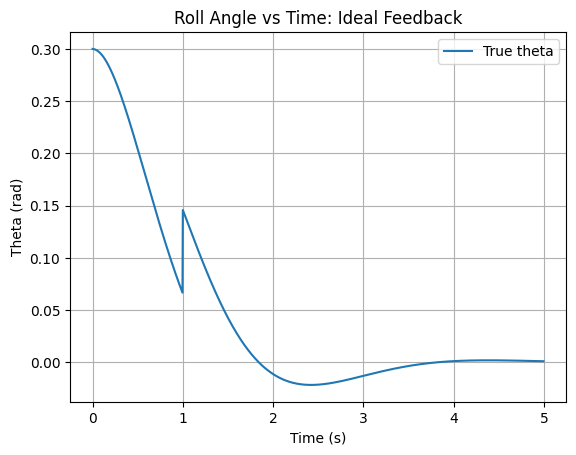

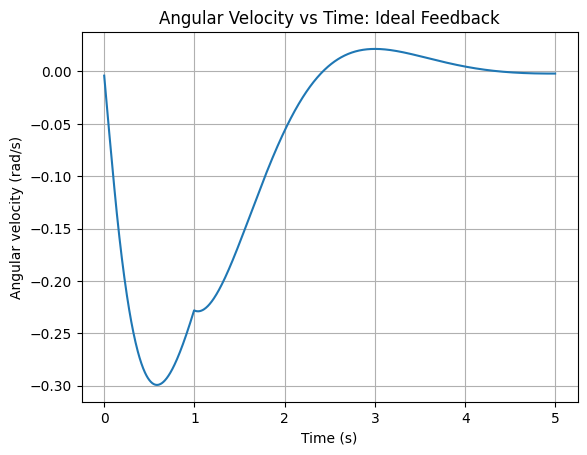

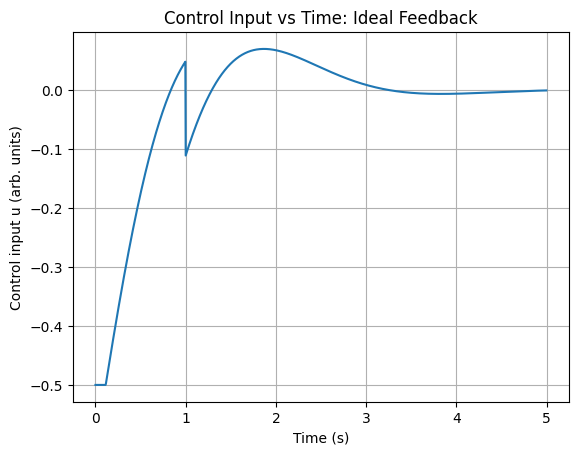

In [4]:
plt.figure()
plt.plot(time_log, theta_log, label="True theta")
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Roll Angle vs Time: Ideal Feedback")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time_log, omega_log)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Angular Velocity vs Time: Ideal Feedback")
plt.grid()
plt.show()

plt.figure()
plt.plot(time_log, motor_log)
plt.xlabel("Time (s)")
plt.ylabel("Control input u (arb. units)")
plt.title("Control Input vs Time: Ideal Feedback")
plt.grid()
plt.show()

### Interpretation: Ideal Feedback

The ideal-feedback simulation shows that the controller successfully drives the roll angle toward zero. The disturbance at \(t = 1.0\) s causes a visible change in the response, but the controller rejects the disturbance and returns the system to equilibrium.

The response is slightly underdamped, meaning the system overshoots zero by a small amount before settling. This is acceptable because the oscillation decays and does not grow over time.

## 6. IMU-Based Simulation


The next component is to run the simulation with the IMU model enabled. Within this state, the controller does not receive the true state, but rather it receives an estimated roll angle from the complementary filter.


The IMU simulator generates:

- accelerometer measurements from the gravity vector,
- gyroscope measurements from angular velocity,
- Gaussian noise to represent sensor uncertainty.



In [9]:
time_log_imu, theta_log_imu, measured_theta_log_imu, omega_log_imu, motor_log_imu = run_simulation(use_imu=True)

print("IMU simulation complete.")
print(f"Time steps: {len(time_log_imu)}")
print(f"Final theta: {theta_log_imu[-1]:.6f} rad")
print(f"Maximum |theta|: {max(abs(theta) for theta in theta_log_imu):.6f} rad")

IMU simulation complete.
Time steps: 1250
Final theta: 0.001892 rad
Maximum |theta|: 0.299984 rad


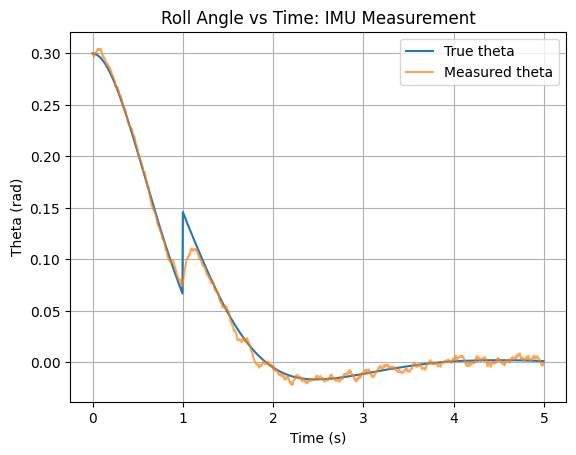

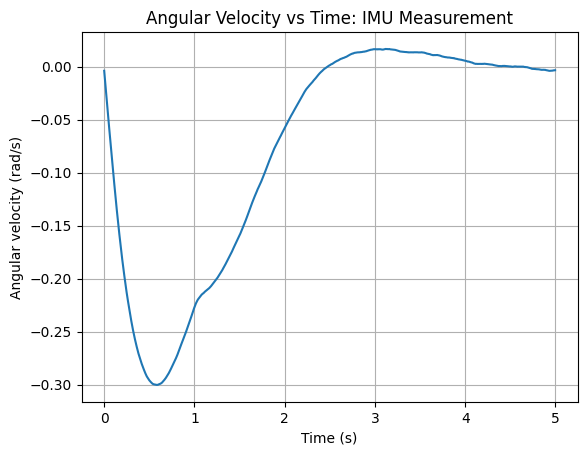

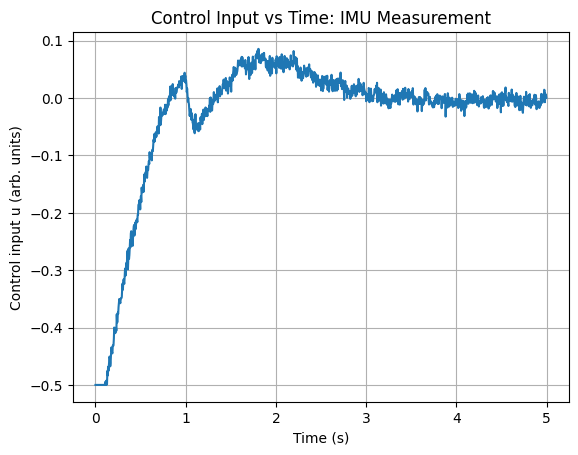

In [6]:
plt.figure()
plt.plot(time_log_imu, theta_log_imu, label="True theta")
plt.plot(time_log_imu, measured_theta_log_imu, label="Measured theta", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Roll Angle vs Time: IMU Measurement")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time_log_imu, omega_log_imu)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Angular Velocity vs Time: IMU Measurement")
plt.grid()
plt.show()

plt.figure()
plt.plot(time_log_imu, motor_log_imu)
plt.xlabel("Time (s)")
plt.ylabel("Control input u (arb. units)")
plt.title("Control Input vs Time: IMU Measurement")
plt.grid()
plt.show()

### Interpretation: IMU Feedback

With the IMU enabled, the measured angle contains small fluctuations due to sensor noise. However, the measured estimate tracks the true angle closely enough for the controller to stabilize the system.

This demonstrates that the controller is not only stable under ideal measurements, but also robust enough to work with noisy sensor data.

## 7. Validation

To check whether the simulation behaves correctly, the following conditions are used:

1. The roll angle should remain within the safety limit of $45^\circ$.
2. The final roll angle should be close to zero.
3. After the disturbance, the system should return toward equilibrium instead of diverging.

In [7]:
def validate_response(theta_log, label):
    max_theta = max(abs(theta) for theta in theta_log)
    final_theta = abs(theta_log[-1])

    print(f"{label}")
    print(f"Maximum |theta|: {max_theta:.6f} rad")
    print(f"Final |theta|: {final_theta:.6f} rad")

    assert max_theta < math.radians(45.0), "Safety limit exceeded."
    assert final_theta < 0.05, "System did not settle close enough to zero."

    print("Validation passed.\n")

validate_response(theta_log, "Ideal feedback")
validate_response(theta_log_imu, "IMU feedback")

Ideal feedback
Maximum |theta|: 0.299984 rad
Final |theta|: 0.001139 rad
Validation passed.

IMU feedback
Maximum |theta|: 0.299984 rad
Final |theta|: 0.001160 rad
Validation passed.



## 8. Discussion

The simulation successfully demonstrates stable single-axis roll control. The PD controller provides a restoring response through the proportional term and damping through the angular-rate term.

A key design choice was using measured angular velocity for the derivative-like term instead of numerically differentiating the error. This reduces noise amplification, which is especially important when using the IMU simulation.

The semi-implicit Euler method was chosen because it is simple, appropriate for a fixed-timestep simulation, and stable for the chosen parameters. Although higher-order methods such as Runge-Kutta could improve accuracy, the Euler-based method is sufficient for demonstrating the control behavior and numerical update process.

### Strengths

- Modular code structure
- Stable closed-loop control
- Disturbance rejection
- IMU noise modeling
- Complementary filtering
- Validation checks

### Limitations

- Only one rotational axis is modeled
- Motor dynamics are simplified
- Control input is treated as an abstract torque
- No full 3D rigid-body dynamics are included
- Battery and calibration modules are simplified support components

## 9. Conclusion

To conclude this project focused upon creating a simplified numerical simulation of a quad copter roll stabilization.  Utilizing semi-implicit Euler integration, a PD control, a simulated IMU sensor, and complementary filtering to stabilize the roll angle of the drone, after the initial offset and disturbance. The results showcase that the system remains stable and returns to a roll angle close to zero in IMU-based measurements mode and ideal-feedback modes.

Future iterations of this project could include:

- full 3D roll, pitch, and yaw dynamics,
- more realistic motor response,
- PID control with integral correction,
- comparison with higher-order integration methods,
- visualization of gain tuning and underdamped/overdamped behavior.


## Disclosure of LLM Usage


During the course of this project I utilized ChatGPT, as an aide in developing, organizing and explaining the systems that were put into place. The primary purpose for utilizing this model was troubleshooting, refining the code to remove redundancy and creating this notebook. The main issues that were resolved with it includes identifying unit inconsistency, derivative noise amplification, accelerometer axis reconstruction, and README/report structure. All of the content was personally reviewed and edited after it was generated to ensure accuracy and improve my understanding as to what was happening.
